# Young Workers in AI-Exposed Occupations: Evidence from Public CPS Microdata

Do early-career workers lose ground in occupations most exposed to generative AI after ChatGPT's release (30 Nov 2022)? Brynjolfsson, Chandar & Chen (2025) document such a decline using proprietary ADP payroll data. This notebook asks whether the pattern is visible in **fully public** data: the Census Bureau's Current Population Survey (CPS) basic monthly microdata, merged with the occupation-level GPT exposure scores of Eloundou et al. (2024).

The notebook runs end to end from a cold start: download → exposure crosswalk → parse and clean → validate against BLS → figures → event study → robustness. Every assertion below is a check the pipeline must pass.

In [1]:
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

ROOT = Path.cwd()
RAW, CLEAN, RES = ROOT / "data" / "raw", ROOT / "data" / "clean", ROOT / "results"
for p in [RAW / "cps", RAW / "exposure", RAW / "bls", CLEAN, RES]:
    p.mkdir(parents=True, exist_ok=True)

START = "2021Q1"   # after the 2020 pandemic collapse
BASE = "2022Q3"    # last full quarter before ChatGPT (released 30 Nov 2022)
YOUNG = (22, 25)

## 1. Download

- **CPS basic monthly files, Jan 2020 – Aug 2026.** CPS adopted 2018 Census occupation codes in January 2020, so this window uses one occupation coding throughout and needs no cross-vintage crosswalk.
- **October 2025 does not exist.** The household survey was not collected during the federal shutdown (Oct 1 – Nov 12, 2025), and BLS publishes no estimate for that month.
- **Exposure scores** from the replication repository of Eloundou et al. (2024); the Census occupation → SOC crosswalk; and the BLS employment series used for validation.

Files are fetched once; existing files are skipped (~790 MB in total).

In [2]:
CPS_URL = "https://www2.census.gov/programs-surveys/cps/datasets/{year}/basic/{name}"
MONTHS = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
FIRST, LAST = (2020, 1), (2026, 8)
KNOWN_MISSING = {(2025, 10)}  # not collected: federal shutdown


def fetch(url, dest):
    if dest.exists() and dest.stat().st_size > 0:
        return
    tmp = dest.with_suffix(dest.suffix + ".part")
    urllib.request.urlretrieve(url, tmp)
    tmp.rename(dest)


fetch("https://raw.githubusercontent.com/openai/GPTs-are-GPTs/main/data/occ_level.csv", RAW / "exposure" / "occ_level.csv")
fetch(CPS_URL.format(year=2026, name="cps_occupation_codes.csv"), RAW / "cps" / "cps_occupation_codes.csv")
fetch("https://fred.stlouisfed.org/graph/fredgraph.csv?id=LNU02000000", RAW / "bls" / "LNU02000000.csv")

months = [(y, m) for y in range(FIRST[0], LAST[0] + 1) for m in range(1, 13)
          if FIRST <= (y, m) <= LAST and (y, m) not in KNOWN_MISSING]
for y, m in months:
    name = f"{MONTHS[m - 1]}{y % 100:02d}pub.zip"
    fetch(CPS_URL.format(year=y, name=name), RAW / "cps" / name)
print(f"{len(months)} CPS months on disk")

79 CPS months on disk


## 2. Exposure crosswalk: O\*NET → SOC → Census occupation

Exposure scores are defined for 8-digit O\*NET-SOC occupations; the CPS codes occupations with 2018 Census codes. The chain is O\*NET-SOC → 6-digit 2018 SOC → Census code. The Census crosswalk expresses aggregated occupations in four ways, each handled explicitly:

1. **Combined categories** list their member SOC codes on `combines-item` rows; those members are used.
2. **Wildcard codes** such as `15-124X` match by prefix.
3. **Broad-group codes** ending in 0 (`13-2070`, `25-1000`) match on the prefix left after stripping trailing zeros.
4. **"All other" residual codes** (`21-1019`) have no O\*NET profile and fall back to their broad group, then minor group.

The headline measure is β = E1 + 0.5·E2, rated by GPT-4 (`exp_gpt4`) and, for robustness, by human annotators (`exp_human`). Scores are the unweighted mean across matched O\*NET occupations.

In [3]:
SCORES = {"dv_rating_beta": "exp_gpt4", "human_rating_beta": "exp_human"}


def census_to_soc_patterns(xwalk):
    summary, items, titles, current = {}, {}, {}, None
    for rtype, code, soc, title in xwalk.itertuples(index=False):
        if rtype == "detail":
            current = code
            titles[code] = title
            summary[code] = [soc] if isinstance(soc, str) else []
            items[code] = []
        elif rtype == "combines-item" and current is not None:
            items[current].append(soc)
        else:
            current = None
    # When a combined category lists its member SOC codes, use those; else the summary code.
    return {c: (titles[c], items[c] or summary[c]) for c in titles}


def match(pattern, soc6):
    if "X" in pattern:
        prefix = pattern[: pattern.index("X")]
        return [s for s in soc6 if s.startswith(prefix)], "wildcard"
    if pattern in soc6:
        return [pattern], "exact"
    if pattern.endswith("0"):
        prefix = pattern.rstrip("0")
        return [s for s in soc6 if s.startswith(prefix)], "broad"
    if pattern.endswith("9"):
        for k in (6, 5):
            m = [s for s in soc6 if s.startswith(pattern[:k])]
            if m:
                return m, "residual"
    return [], "none"


onet = pd.read_csv(RAW / "exposure" / "occ_level.csv", dtype={"O*NET-SOC Code": str})
onet["soc6"] = onet["O*NET-SOC Code"].str[:7]
soc_scores = onet.groupby("soc6")[list(SCORES)].mean().rename(columns=SCORES)
soc6 = set(soc_scores.index)

xwalk = pd.read_csv(RAW / "cps" / "cps_occupation_codes.csv", dtype=str, encoding="utf-8-sig")
rows = []
for code, (title, patterns) in census_to_soc_patterns(xwalk).items():
    matched, methods = [], []
    for p in patterns:
        m, how = match(p, soc6)
        matched += m
        methods.append(how)
    matched = sorted(set(matched))
    rec = {"occ_code": int(code), "title": title, "n_soc_matched": len(matched),
           "match_method": ";".join(sorted(set(methods)))}
    rec.update(soc_scores.loc[matched].mean().to_dict() if matched else {v: np.nan for v in SCORES.values()})
    rows.append(rec)

exposure = pd.DataFrame(rows).sort_values("occ_code")
exposure.to_csv(CLEAN / "exposure_by_census_occ.csv", index=False)

unmatched = exposure[exposure.n_soc_matched == 0]
print(f"Census occupations: {len(exposure)} | matched: {len(exposure) - len(unmatched)} | unmatched: {unmatched.title.tolist()}")
print(f"Correlation of GPT-4 and human ratings: {exposure[['exp_gpt4', 'exp_human']].corr().iloc[0, 1]:.2f}")
pd.concat([exposure.nlargest(5, "exp_gpt4"), exposure.nsmallest(5, "exp_gpt4")])[["occ_code", "title", "exp_gpt4", "exp_human"]].round(3)

Census occupations: 526 | matched: 525 | unmatched: ['Armed Forces']
Correlation of GPT-4 and human ratings: 0.88


,occ_code,title,exp_gpt4,exp_human
359,5910,Proofreaders and copy markers,0.975,0.600
175,2862,Court reporters and simultaneous captioners,0.958,0.521
61,1010,Computer programmers,0.950,0.683
64,1031,Web developers,0.933,0.635
67,1065,Database administrators and architects,0.923,0.621
160,2721,Athletes and sports competitors,0.000,0.000
262,4130,Dining room and cafeteria attendants and barte...,0.000,0.000
263,4140,Dishwashers,0.000,0.000
268,4220,Janitors and building cleaners,0.000,0.043
269,4230,Maids and housekeeping cleaners,0.000,0.059


## 3. Parse and clean the CPS

Each monthly file is fixed-width: one 1,000-character record per person. Field positions were checked against every year's Census record layout (2020–2026, plus the May 2024 revision) and are identical for all fields used here. The occupation field is named `PEIO1OCD` in 2020 and `PTIO1OCD` afterwards, at the same position (860–863).

Records are sliced as a numpy byte matrix rather than parsed line by line, so a 120 MB month parses in about a second. Universe: civilian adults (`PRPERTYP == 2`) aged 16+. Every step's record count goes into a cleaning waterfall.

In [4]:
RECORD_LEN = 1000
# name: (start, end), 1-indexed inclusive positions from the Census record layout
FIELDS = {
    "year": (18, 21),      # HRYEAR4
    "month": (16, 17),     # HRMONTH
    "mis": (63, 64),       # HRMIS, month-in-sample
    "age": (122, 123),     # PRTAGE (topcoded at 85)
    "educ": (137, 138),    # PEEDUCA
    "pertype": (161, 162), # PRPERTYP: 2 = adult civilian
    "lfs": (180, 181),     # PEMLR: 1-2 employed, 3-4 unemployed, 5-7 NILF
    "cow": (432, 433),     # PEIO1COW: 1-5 wage/salary, 6-7 self-employed, 8 unpaid
    "earnwk": (527, 534),  # PTERNWA weekly earnings, 2 implied decimals (outgoing rotation)
    "orgwgt": (603, 612),  # PWORWGT, 4 implied decimals
    "cmpwgt": (846, 855),  # PWCMPWGT composite weight, 4 implied decimals
    "occ": (860, 863),     # PTIO1OCD / PEIO1OCD, 2018 Census occupation code
}


def parse_month(path):
    with zipfile.ZipFile(path) as z:
        (name,) = z.namelist()
        raw = z.read(name)
    stride = raw.index(b"\n") + 1  # 1001 for \n, 1002 for \r\n line endings
    if stride - RECORD_LEN not in (1, 2):
        raise ValueError(f"{path.name}: unexpected record length {stride}")
    if len(raw) % stride:  # final record without a trailing newline
        raw += b"\n" * (stride - len(raw) % stride)
    mat = np.frombuffer(raw, dtype=np.uint8).reshape(-1, stride)

    cols = {}
    for name, (a, b) in FIELDS.items():
        s = np.ascontiguousarray(mat[:, a - 1:b]).view(f"S{b - a + 1}").ravel()
        cols[name] = pd.to_numeric(pd.Series(s).str.decode("ascii").str.strip(), errors="coerce")
    df = pd.DataFrame(cols)
    df["cmpwgt"] /= 1e4
    df["orgwgt"] /= 1e4
    df["earnwk"] = df["earnwk"].where(df["earnwk"] >= 0) / 100
    return df


frames, steps = [], []
for f in sorted((RAW / "cps").glob("*pub.zip")):
    df = parse_month(f)
    n_raw = len(df)
    ym = df[["year", "month"]].drop_duplicates()
    assert len(ym) == 1, f"{f.name}: multiple year-months"  # file is the month its name says
    year, month = map(int, ym.iloc[0])

    df = df[df.pertype == 2]
    n_adult = len(df)
    df = df[df.age >= 16]
    assert df.lfs.between(1, 7).all(), f"{f.name}: labor force status out of range"
    assert (df.cmpwgt >= 0).all(), f"{f.name}: negative weight"

    steps.append({"year": year, "month": month, "raw_records": n_raw, "adult_civilian": n_adult,
                  "age_16plus": len(df), "employed": int(df.lfs.isin([1, 2]).sum()),
                  "employed_with_occ": int((df.lfs.isin([1, 2]) & (df.occ > 0)).sum())})
    frames.append(df.drop(columns="pertype"))

cps = pd.concat(frames, ignore_index=True).astype(
    {"year": "int16", "month": "int8", "mis": "int8", "age": "int8", "educ": "int8", "lfs": "int8",
     "cow": "int8", "occ": "int16", "cmpwgt": "float32", "orgwgt": "float32", "earnwk": "float32"})
cps.to_parquet(CLEAN / "cps_2020_2026.parquet", index=False)

waterfall = pd.DataFrame(steps).sort_values(["year", "month"])
waterfall.to_csv(RES / "cleaning_waterfall.csv", index=False)
print(f"{len(waterfall)} months parsed -> {len(cps):,} person-month rows")
waterfall.drop(columns=["year", "month"]).sum().rename("records (pooled)").to_frame().style.format("{:,}")

79 months parsed -> 6,464,072 person-month rows


,records (pooled)
raw_records,"10,037,598"
adult_civilian,"6,564,159"
age_16plus,"6,464,072"
employed,"3,722,523"
employed_with_occ,"3,722,523"


## 4. Validation against published BLS statistics

If the field positions and weights are read correctly, weighted employment must reproduce the official BLS series (LNU02000000, employment level, not seasonally adjusted) in every month. A second check confirms that every employed worker's occupation carries an exposure score.

In [5]:
emp = cps[cps.lfs.isin([1, 2])].groupby(["year", "month"]).cmpwgt.sum().div(1e3).rename("cps_thousands").reset_index()
emp["date"] = pd.to_datetime(dict(year=emp.year, month=emp.month, day=1))
bls = pd.read_csv(RAW / "bls" / "LNU02000000.csv", names=["date", "bls_thousands"], header=0, parse_dates=["date"])
check = emp.merge(bls, on="date", how="left")
check["pct_diff"] = 100 * (check.cps_thousands / check.bls_thousands - 1)

assert check.bls_thousands.notna().all(), "a CPS month has no BLS counterpart"
assert check.pct_diff.abs().max() < 0.01, "CPS employment does not reproduce BLS"
print(f"{len(check)} months: max |CPS - BLS| = {check.pct_diff.abs().max():.4f}%  OK")

employed = cps[cps.lfs.isin([1, 2])]
share_matched = employed.occ.isin(exposure.dropna(subset=["exp_gpt4"]).occ_code).mean()
assert share_matched == 1.0
print(f"Employed person-months with an exposure score: {share_matched:.1%}  OK")
check[["date", "cps_thousands", "bls_thousands", "pct_diff"]].iloc[::12].round({"cps_thousands": 0, "bls_thousands": 0, "pct_diff": 4})

79 months: max |CPS - BLS| = 0.0003%  OK


Employed person-months with an exposure score: 100.0%  OK


,date,cps_thousands,bls_thousands,pct_diff
0,2020-01-01,156994.0,156994.0,-0.0002
12,2021-01-01,148383.0,148383.0,-0.0001
24,2022-01-01,155618.0,155618.0,0.0002
36,2023-01-01,158692.0,158692.0,-0.0003
48,2024-01-01,159650.0,159650.0,-0.0001
60,2025-01-01,162347.0,162347.0,0.0001
72,2026-02-01,162153.0,162153.0,0.0002


## 5. Employment by exposure quintile

Analysis sample: employed workers, 2021Q1 onward (after the 2020 pandemic collapse). Quarterly employment is the mean of the available months' weighted totals, so the missing October 2025 does not bias 2025Q4.

Quintiles are employment-weighted: each holds about 20% of 2022 employment. Employment is indexed to 2022Q3, the last full quarter before ChatGPT.

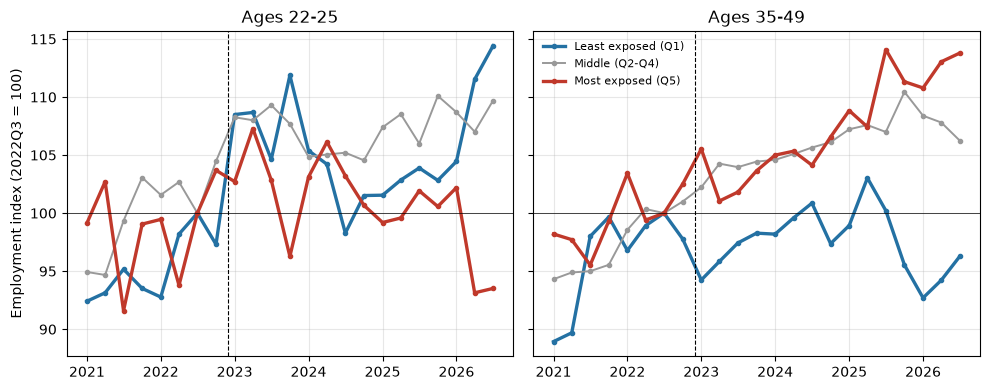

22-25 year-olds employed per month (sample size): ~3,167


In [6]:
d = cps[cps.lfs.isin([1, 2]) & (cps.occ > 0)].merge(
    exposure[["occ_code", "exp_gpt4", "exp_human"]], left_on="occ", right_on="occ_code", how="inner")
d["q"] = pd.PeriodIndex(pd.to_datetime(dict(year=d.year, month=d.month, day=1)), freq="Q")
d = d[d.q >= pd.Period(START, "Q")]


def quarterly(cells, keys):
    m = cells.groupby(keys + ["q", "year", "month"]).cmpwgt.sum().reset_index()
    return m.groupby(keys + ["q"]).cmpwgt.mean().rename("emp").reset_index()


def assign_quintiles(d, col):
    base = d[d.year == 2022].groupby("occ").agg(emp=("cmpwgt", "sum"), x=(col, "first")).sort_values("x")
    base["cum"] = base.emp.cumsum() / base.emp.sum()
    return np.minimum(np.ceil(base.cum * 5), 5).astype(int)


labels = {1: "Least exposed (Q1)", 5: "Most exposed (Q5)"}
dq = d.assign(quintile=d.occ.map(assign_quintiles(d, "exp_gpt4")).map(labels).fillna("Middle (Q2-Q4)"))
colors = {"Least exposed (Q1)": "#2471a3", "Middle (Q2-Q4)": "0.6", "Most exposed (Q5)": "#c0392b"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (label, lo, hi) in zip(axes, [("Ages 22-25", *YOUNG), ("Ages 35-49", 35, 49)]):
    q = quarterly(dq[dq.age.between(lo, hi)], ["quintile"])
    base_emp = q[q.q == pd.Period(BASE, "Q")].set_index("quintile").emp
    q["index"] = 100 * q.emp / q.quintile.map(base_emp)
    for k, g in q.groupby("quintile"):
        ax.plot(g.q.dt.to_timestamp(), g["index"], label=k, color=colors[k],
                lw=1.4 if k.startswith("Middle") else 2.4, marker="o", ms=3)
    ax.axvline(pd.Timestamp("2022-11-30"), color="k", ls="--", lw=0.8)
    ax.axhline(100, color="k", lw=0.5)
    ax.set_title(label)
    ax.grid(alpha=0.3)
axes[0].set_ylabel(f"Employment index ({BASE} = 100)")
axes[1].legend(fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(RES / "fig1_index_by_quintile.png", dpi=200)
plt.show()
print(f"22-25 year-olds employed per month (sample size): ~{len(d[d.age.between(*YOUNG)]) / d.groupby(['year', 'month']).ngroups:,.0f}")

## 6. Event study

Occupation × quarter panel. For occupation $o$ in quarter $t$:

$$\text{YoungShare}_{ot} = \alpha_o + \lambda_t + \sum_{k \neq \text{2022Q3}} \beta_k \cdot \text{Exposure}_o \cdot \mathbb{1}[t = k] + \varepsilon_{ot}$$

- $\text{YoungShare}_{ot}$: share of occupation employment aged 22–25 (percentage points).
- $\text{Exposure}_o$: standardized GPT-4 exposure.
- $\alpha_o, \lambda_t$: occupation and quarter fixed effects; weights are 2022 occupation employment; SEs are clustered by occupation.

$\beta_k$ asks whether the young share moved differently in more-exposed occupations in quarter $k$, relative to 2022Q3. Coefficients near zero before ChatGPT support the parallel-trends assumption.

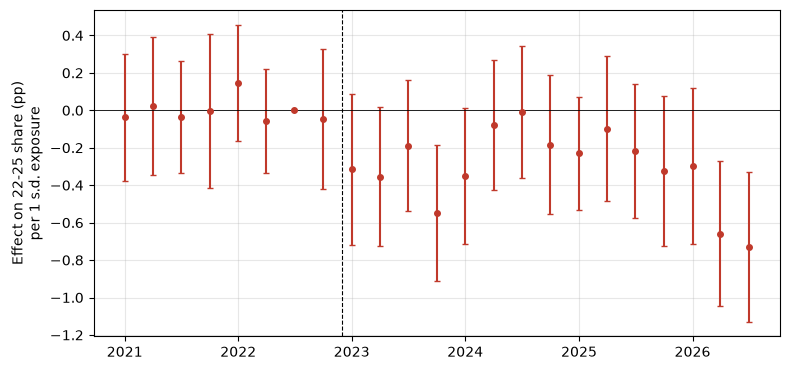

q,2021Q1,2021Q2,2021Q3,2021Q4,2022Q1,2022Q2,2022Q3,2022Q4,2023Q1,2023Q2,...,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1,2026Q2,2026Q3
coef,-0.038,0.023,-0.037,-0.005,0.148,-0.058,0.0,-0.048,-0.316,-0.355,...,-0.078,-0.009,-0.184,-0.229,-0.098,-0.218,-0.324,-0.297,-0.659,-0.730
lo,-0.377,-0.343,-0.336,-0.416,-0.161,-0.336,0.0,-0.422,-0.721,-0.727,...,-0.426,-0.362,-0.556,-0.530,-0.484,-0.575,-0.727,-0.715,-1.045,-1.128
hi,0.302,0.389,0.263,0.406,0.457,0.219,0.0,0.326,0.089,0.016,...,0.270,0.344,0.189,0.072,0.288,0.138,0.078,0.121,-0.273,-0.331


In [7]:
def occ_panel(d, exp_col="exp_gpt4", young=YOUNG):
    q_all = quarterly(d, ["occ"])
    q_young = quarterly(d[d.age.between(*young)], ["occ"]).rename(columns={"emp": "emp_young"})
    p = q_all.merge(q_young, on=["occ", "q"], how="left").fillna({"emp_young": 0})
    p["young_share"] = 100 * p.emp_young / p.emp
    w = d[d.year == 2022].groupby("occ").cmpwgt.sum().rename("w")
    x = d.groupby("occ")[exp_col].first()
    p = p.merge(w, on="occ").merge(((x - x.mean()) / x.std()).rename("exposure"), on="occ")
    return p[p.w > 0]


def event_study(p):
    p = p.copy()
    terms = []
    for k in sorted(p.q.unique()):
        if k == pd.Period(BASE, "Q"):
            continue
        p[f"x_{k}"] = p.exposure * (p.q == k)
        terms.append(f"x_{k}")
    p["qs"] = p.q.astype(str)
    fit = smf.wls(f"young_share ~ {' + '.join(terms)} + C(occ) + C(qs)", data=p, weights=p.w).fit(
        cov_type="cluster", cov_kwds={"groups": p.occ})
    ci = fit.conf_int()
    out = pd.DataFrame({"q": [t[2:] for t in terms], "coef": fit.params[terms].values,
                        "lo": ci.loc[terms, 0].values, "hi": ci.loc[terms, 1].values})
    return pd.concat([out, pd.DataFrame([{"q": BASE, "coef": 0.0, "lo": 0.0, "hi": 0.0}])]).sort_values("q")


base_panel = occ_panel(d)
es = event_study(base_panel)
es.to_csv(RES / "event_study.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 3.8))
x = pd.PeriodIndex(es.q, freq="Q").to_timestamp()
ax.errorbar(x, es.coef, yerr=[es.coef - es.lo, es.hi - es.coef], fmt="o", color="#c0392b", ms=4, capsize=2)
ax.axhline(0, color="k", lw=0.6)
ax.axvline(pd.Timestamp("2022-11-30"), color="k", ls="--", lw=0.8)
ax.set_ylabel("Effect on 22-25 share (pp)\nper 1 s.d. exposure")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RES / "fig2_event_study.png", dpi=200)
plt.show()
es.round(3).set_index("q").T

## 7. Pooled estimate and robustness

The pooled version replaces the quarter-by-quarter coefficients with a single $\text{Exposure}_o \times \text{Post}_t$ term. The checks:

- **(2)–(4)** Alternative exposure rating, worker definition, and age band.
- **(5)** Drops computer & math occupations (Census codes 1005–1240). The 2023 tech layoff wave, driven by interest rates rather than AI, hit exactly these highly exposed occupations.
- **(6)** Ends the sample in 2025Q4, so the estimate does not rest on 2026 alone.
- **(7)** Placebo: a fake event in 2021Q4, estimated on pre-ChatGPT data only. A real effect should not appear here.
- **(8)** Composition check, not a placebo: shares sum to 100, so a falling young share must show up as rising shares elsewhere.

In [8]:
def pooled(p, event=BASE, end=None):
    if end is not None:
        p = p[p.q <= pd.Period(end, "Q")]
    p = p.assign(post=(p.q > pd.Period(event, "Q")).astype(int), qs=p.q.astype(str))
    fit = smf.wls("young_share ~ exposure:post + C(occ) + C(qs)", data=p, weights=p.w).fit(
        cov_type="cluster", cov_kwds={"groups": p.occ})
    at = p.q == pd.Period(event, "Q")
    return {"coef": fit.params["exposure:post"], "se": fit.bse["exposure:post"],
            "p": fit.pvalues["exposure:post"],
            "base_mean": np.average(p.loc[at, "young_share"], weights=p.loc[at, "w"]),
            "n_occ": p.occ.nunique(), "n_obs": len(p)}


computer = d.occ.between(1005, 1240)
specs = {
    "(1) Baseline: GPT-4 exposure, ages 22-25": pooled(base_panel),
    "(2) Human-rated exposure": pooled(occ_panel(d, exp_col="exp_human")),
    "(3) Wage and salary workers only": pooled(occ_panel(d[d.cow.between(1, 5)])),
    "(4) Ages 22-29": pooled(occ_panel(d, young=(22, 29))),
    "(5) Excluding computer & math occupations": pooled(occ_panel(d[~computer])),
    "(6) Sample ends 2025Q4": pooled(base_panel, end="2025Q4"),
    "(7) Placebo: fake event 2021Q4, pre-ChatGPT data only": pooled(base_panel, event="2021Q4", end=BASE),
    "(8) Composition check: ages 35-49": pooled(occ_panel(d, young=(35, 49))),
}
table = pd.DataFrame(specs).T.astype({"n_occ": int, "n_obs": int})
table.to_csv(RES / "table2_pooled.csv")

b = table.iloc[0]
print(f"Baseline: {b.coef:.3f} pp per s.d. on a 2022Q3 mean of {b.base_mean:.2f}% "
      f"= {100 * b.coef / b.base_mean:.1f}% relative change")
table.style.format({"coef": "{:.3f}", "se": "{:.3f}", "p": "{:.3f}", "base_mean": "{:.2f}"})

Baseline: -0.294 pp per s.d. on a 2022Q3 mean of 7.74% = -3.8% relative change


,coef,se,p,base_mean,n_occ,n_obs
"(1) Baseline: GPT-4 exposure, ages 22-25",-0.294,0.089,0.001,7.74,525,12063
(2) Human-rated exposure,-0.290,0.090,0.001,7.74,525,12063
(3) Wage and salary workers only,-0.308,0.096,0.001,8.34,525,12054
(4) Ages 22-29,-0.415,0.119,0.000,16.37,525,12063
(5) Excluding computer & math occupations,-0.308,0.092,0.001,7.72,509,11695
(6) Sample ends 2025Q4,-0.231,0.089,0.009,7.74,525,10490
"(7) Placebo: fake event 2021Q4, pre-ChatGPT data only",0.044,0.124,0.721,7.90,525,3672
(8) Composition check: ages 35-49,0.531,0.133,0.000,31.66,525,12063


## Limitations

- Exposure measures *potential* task exposure, not actual AI use.
- Young-worker cells are small (about 3,200 employed 22–25 year-olds per month). Quarterly averaging reduces noise, but individual quarters remain imprecise.
- High-exposure occupations may face other post-2022 shocks (interest rates, hiring cycles). Specification (5) removes the most obvious one but cannot rule out all of them; the estimates are descriptive, not causal.

## References

- Brynjolfsson, E., Chandar, B., & Chen, R. (2025). Canaries in the Coal Mine? Six Facts about the Recent Employment Effects of Artificial Intelligence. Stanford Digital Economy Lab working paper.
- Eloundou, T., Manning, S., Mishkin, P., & Rock, D. (2024). GPTs are GPTs: Labor market impact potential of LLMs. *Science*, 384(6702).
- U.S. Census Bureau. Current Population Survey basic monthly public-use files, 2020–2026.
- U.S. Bureau of Labor Statistics. Employment level, LNU02000000 (via FRED).